In [1]:
# Core Data & Math
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# NLP Utilities
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

#  Scikit-learn: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Scikit-learn: Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn: Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# Model Saving
import joblib   # to save model + vectorizer as .pkl files for app.py

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

#  Global Plot Style
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {
    'joy':      '#F9C74F',
    'sadness':  '#577590',
    'anger':    '#F94144',
    'fear':     '#9B5DE5',
    'love':     '#F3722C',
    'surprise': '#90BE6D'
}


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Load the dataset — semicolon-separated, no header row
df = pd.read_csv('train.txt', sep=';', header=None, names=['text', 'emotion'])

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head(10)

Dataset shape : (16000, 2)
Columns       : ['text', 'emotion']


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


df.head()

## Exploratory Data Analysis(EDA)

In [3]:
#  Basic Dataset infornmation i.e. Shape, types, nulls, duplicates 
print("Dataset Infornmation")
print(f'Total rows    : {len(df)}')
print(f'Total columns : {df.shape[1]}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'\nUnique emotions: {list(df["emotion"].unique())}')

Dataset Infornmation
Total rows    : 16000
Total columns : 2

Data types:
text       object
emotion    object
dtype: object

Missing values:
text       0
emotion    0
dtype: int64

Duplicate rows: 1

Unique emotions: ['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']


## Univariate Analysis — emotion Column

          count  percentage
emotion                    
joy        5362       33.51
sadness    4666       29.16
anger      2159       13.49
fear       1937       12.11
love       1304        8.15
surprise    572        3.58


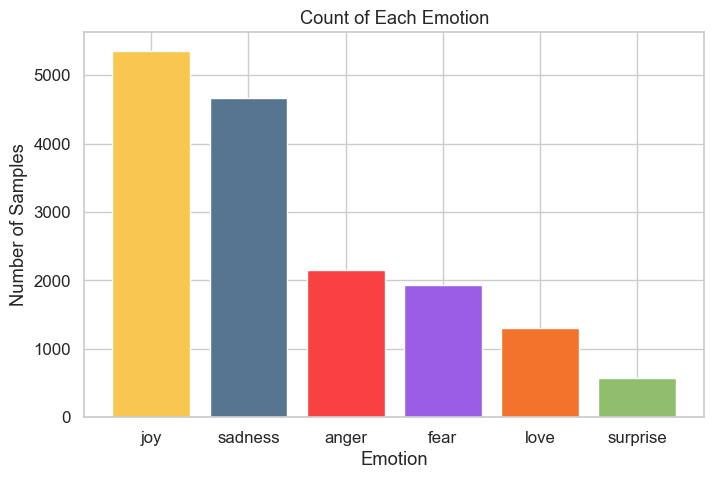

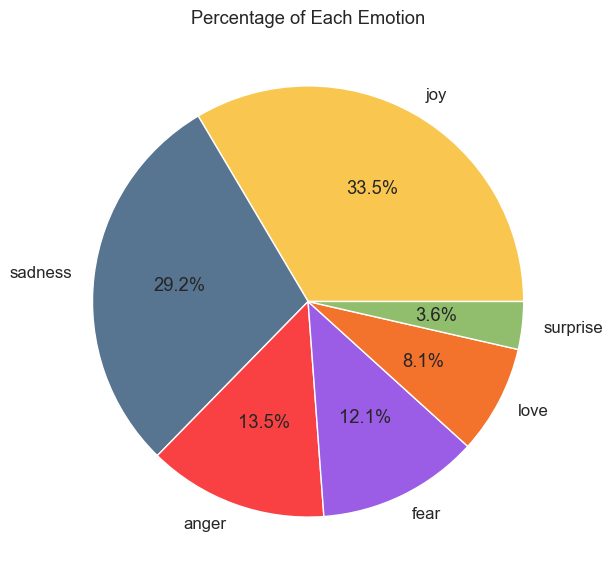

In [4]:
# How many samples does each emotion have?

# Count each emotion
emotion_counts = df['emotion'].value_counts()
emotion_pct    = df['emotion'].value_counts(normalize=True) * 100

# Print the table
print(pd.DataFrame({'count': emotion_counts, 'percentage': emotion_pct.round(2)}))

# Colors for each emotion
colors = [PALETTE[e] for e in emotion_counts.index]

#  BAR CHART
plt.figure(figsize=(8, 5))
plt.bar(emotion_counts.index, emotion_counts.values, color=colors)
plt.title('Count of Each Emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.show()

# PIE CHART
plt.figure(figsize=(7, 7))
plt.pie(emotion_pct.values,
        labels=emotion_pct.index,
        colors=colors,
        autopct='%1.1f%%')
plt.title('Percentage of Each Emotion')
plt.show()

## Univariate Analysis — text column

Text Length Statistics
       text_length  word_count
count     16000.00    16000.00
mean         96.85       19.17
std          55.90       10.99
min           7.00        2.00
25%          53.00       11.00
50%          86.00       17.00
75%         129.00       25.00
max         300.00       66.00


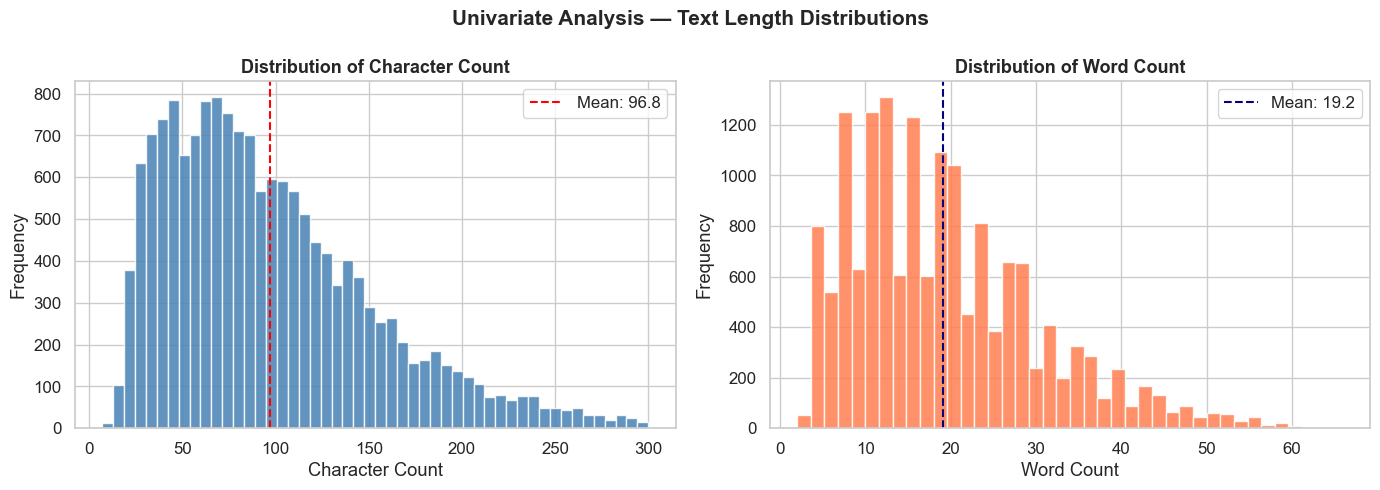

In [5]:
#  Univariate: How long are the sentences?
# Adds two columns: character count and word count for each sentence

df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

print("Text Length Statistics")
print(df[['text_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['text_length'].mean():.1f}")
axes[0].set_title('Distribution of Character Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count distribution
axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(df['word_count'].mean(), color='navy', linestyle='--',
                label=f"Mean: {df['word_count'].mean():.1f}")
axes[1].set_title('Distribution of Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Univariate Analysis — Text Length Distributions',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

## Bivariate Analysis — Text Length(text column) per Emotion(emotion Column)

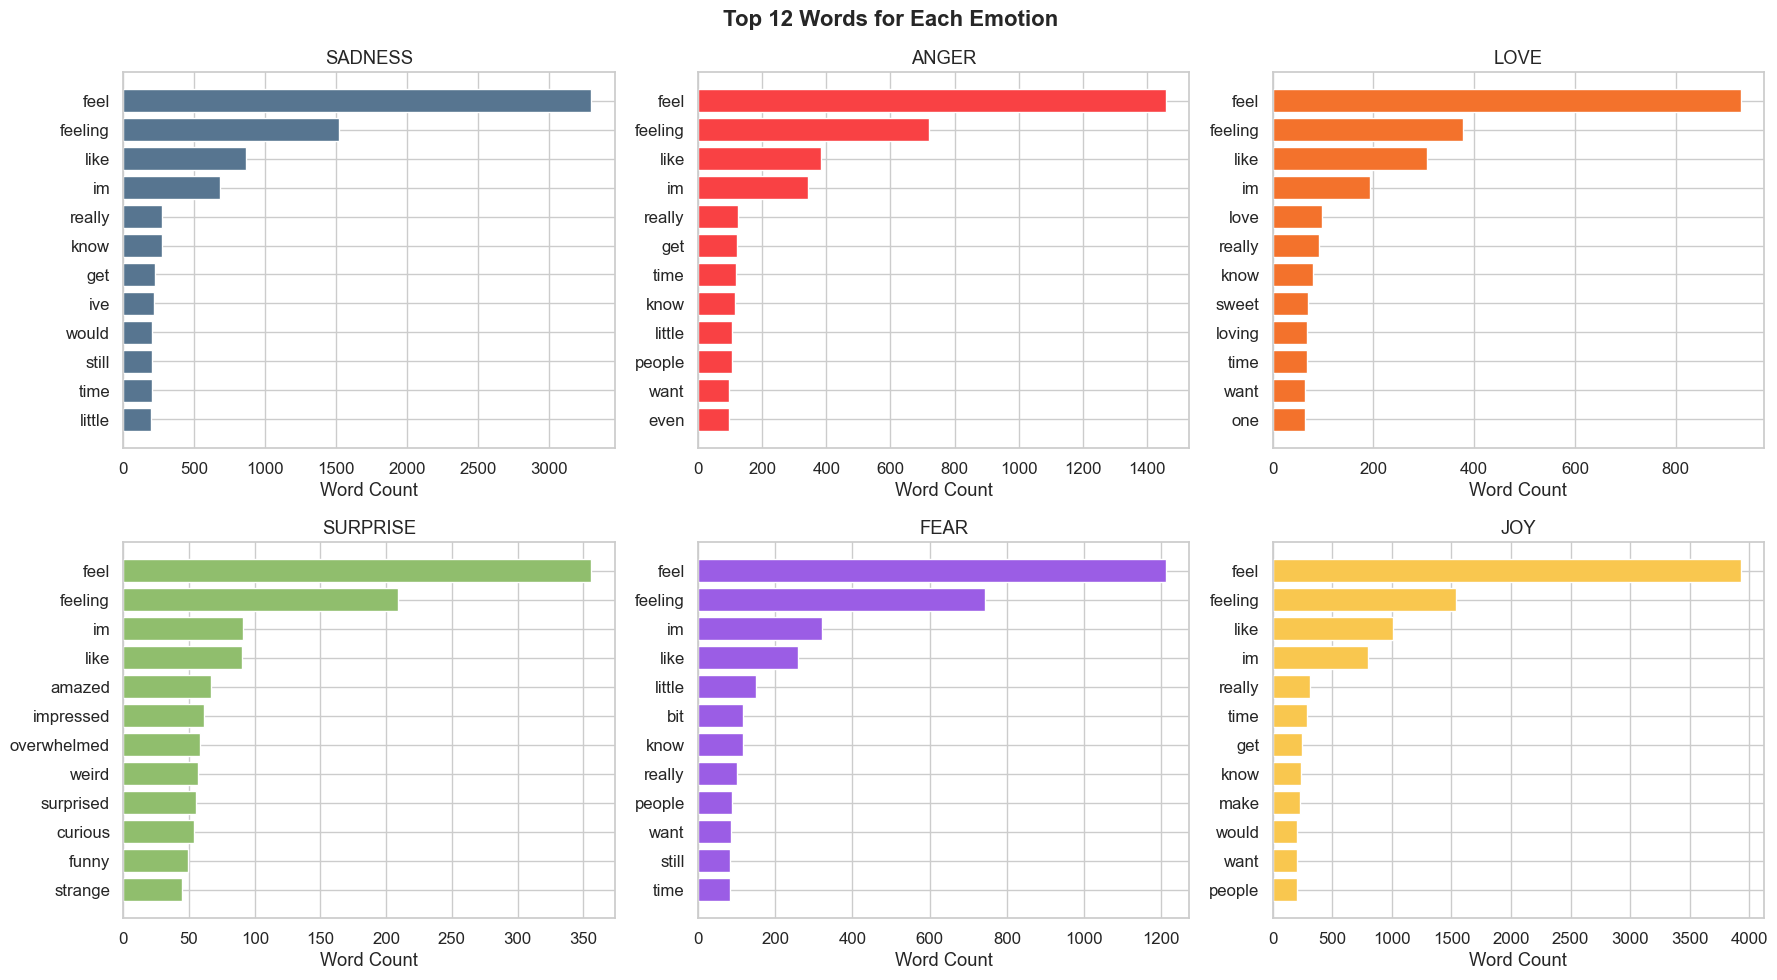

In [19]:
# Which words are used most in each emotion?

# Load stopwords - these are common words we want to ignore
# Example stopwords: 'the', 'is', 'a', 'an', 'i', 'was'
stop_words = set(stopwords.words('english'))

# Function to find top 12 most used words for a given emotion
def get_top_words(emotion_df):
    all_words = []

    # Go through each sentence one by one
    for sentence in emotion_df['text']:

        # Split sentence into individual words
        words = word_tokenize(sentence.lower())

        # Keep only real words and remove stopwords
        for word in words:
            if word.isalpha() and word not in stop_words:
                all_words.append(word)

    # Count all words and return top 12
    top_12 = Counter(all_words).most_common(12)
    return top_12


# Get list of all emotions
emotions = df['emotion'].unique()

# Create 6 charts in a grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop through each emotion and draw its chart
for i, emotion in enumerate(emotions):

    # Get only rows belonging to this emotion
    emotion_data = df[df['emotion'] == emotion]

    # Find top 12 words for this emotion
    top_12 = get_top_words(emotion_data)

    # Separate into two lists: words and their counts
    words  = [item[0] for item in top_12]
    counts = [item[1] for item in top_12]

    # Draw horizontal bar chart
    axes[i].barh(words[::-1], counts[::-1], color=PALETTE[emotion])
    axes[i].set_title(emotion.upper())
    axes[i].set_xlabel('Word Count')

plt.suptitle('Top 12 Words for Each Emotion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Bivariate Analysis — Top Words(text column) per Emotion(emotion column)

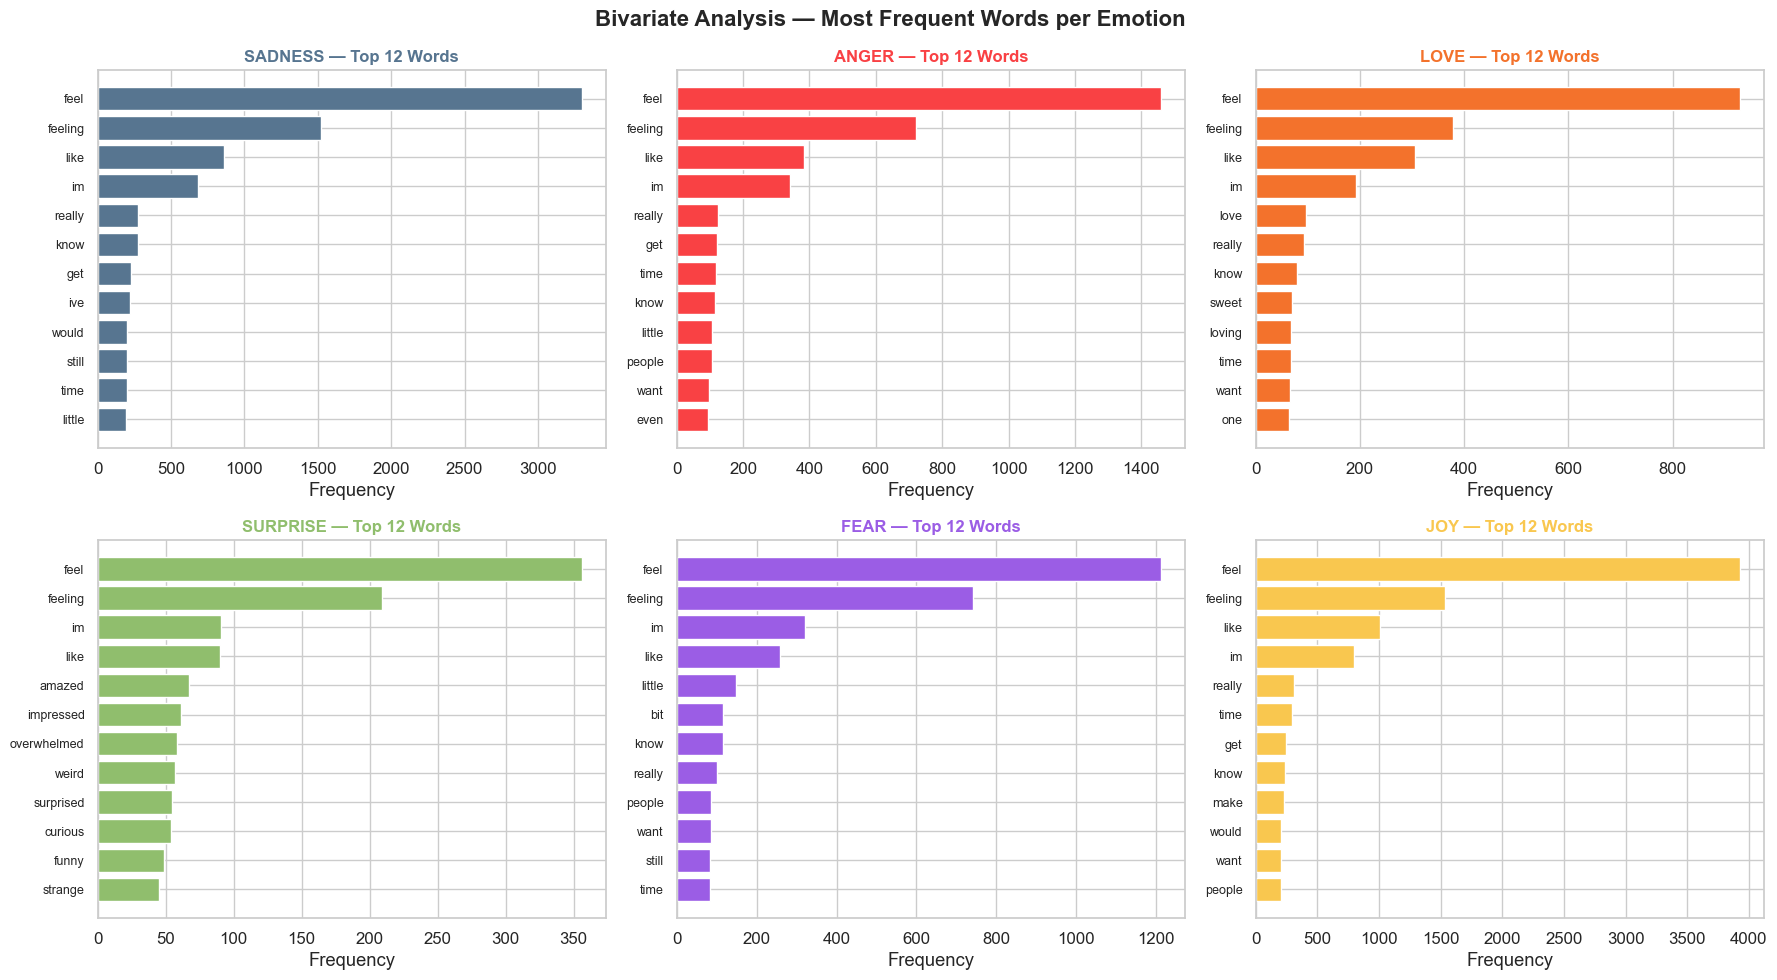

In [7]:
# Bivariate: Which words dominate each emotion class? 
# Reveals vocabulary that is emotionally diagnostic

stop_words = set(stopwords.words('english'))

def get_top_words(emotion_df, n=12):
    # Tokenize all texts for one emotion and return top-n words.
    all_words = []
    for text in emotion_df['text']:
        tokens = word_tokenize(str(text).lower())
        words  = [w for w in tokens if w.isalpha() and w not in stop_words]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

emotions = df['emotion'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotions):
    subset    = df[df['emotion'] == emotion]
    top_words = get_top_words(subset, n=12)
    words, counts = zip(*top_words)

    axes[i].barh(words[::-1], counts[::-1], color=PALETTE[emotion], edgecolor='white')
    axes[i].set_title(f'{emotion.upper()} — Top 12 Words', fontsize=12,
                      fontweight='bold', color=PALETTE[emotion])
    axes[i].set_xlabel('Frequency')
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Bivariate Analysis — Most Frequent Words per Emotion',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Bivariate Analysis — Avg Word Length(text column) per Emotion(emotion column)

Average stats for each emotion:
          avg_char_len  avg_word_cnt  avg_word_len
emotion                                           
anger            96.91         19.23          4.15
fear             96.12         18.84          4.23
joy              98.55         19.50          4.14
love            104.03         20.70          4.10
sadness          92.55         18.36          4.15
surprise        101.68         19.97          4.18


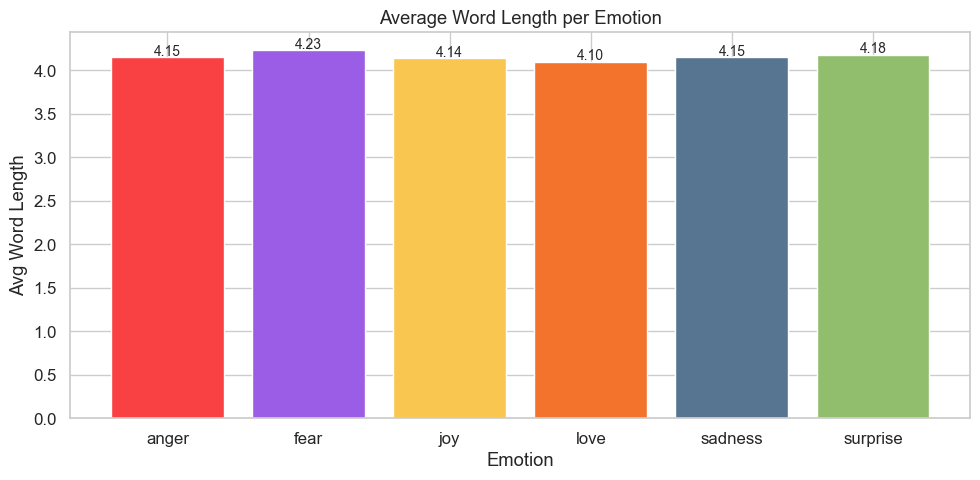

In [8]:
# Average Word Length per Emotion i.e. do some emotions use longer or shorter words?

# Make a function to find average word length in a sentence
def avg_word_len(text):
    words = text.split()          # split into words
    if len(words) == 0:           # if no words found, return 0
        return 0
    total = sum(len(w) for w in words)   # total characters in all words
    average = total / len(words)         # divide by number of words
    return average

# Apply this function to every sentence in the dataset
df['avg_word_length'] = df['text'].apply(avg_word_len)

# Group by emotion and find the mean of each column
grouped_stats = df.groupby('emotion').agg(
    avg_char_len = ('text_length',     'mean'),
    avg_word_cnt = ('word_count',      'mean'),
    avg_word_len = ('avg_word_length', 'mean')
).round(2)

# Print the result table
print('Average stats for each emotion:')
print(grouped_stats)

# Draw a bar chart
fig, ax = plt.subplots(figsize=(10, 5))

# Pick colors for each emotion
colors = [PALETTE[e] for e in grouped_stats.index]

# Draw bars
bars = ax.bar(grouped_stats.index, grouped_stats['avg_word_len'], color=colors)

# Write the value on top of each bar
for bar, val in zip(bars, grouped_stats['avg_word_len']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar
        bar.get_height() + 0.02,             # just above bar
        f'{val:.2f}',                        # value rounded to 2 decimals
        ha='center', fontsize=10
    )

# Add title and axis labels
ax.set_title('Average Word Length per Emotion')
ax.set_xlabel('Emotion')
ax.set_ylabel('Avg Word Length')

plt.tight_layout()
plt.show()


## Text Preprocessing

In [13]:
# We need to remove unnecessary things from each sentence
# so the model only sees useful words

def full_clean(txt):
    txt = to_lowercase(txt)       
    txt = remove_punctuation(txt)  
    txt = remove_numbers(txt)      
    txt = remove_emojis(txt)       
    txt = remove_extra_spaces(txt) 
    txt = remove_stopwords(txt)    
    return txt

# Apply the full_clean function to every row in the 'text' column
# This creates a new column 'clean_text' with the cleaned version
df['clean_text'] = df['text'].apply(full_clean)


# Print 5 examples to see how the text looks before and after cleaning
print("BEFORE vs AFTER CLEANING(5 examples)")
print()
for i, row in df.sample(5, random_state=42).iterrows():
    print(f'ORIGINAL : {row["text"]}')
    print(f'CLEANED  : {row["clean_text"]}')
    print('---')


BEFORE vs AFTER CLEANING(5 examples)

ORIGINAL : ive made it through a week i just feel beaten down
CLEANED  : ive made week feel beaten
---
ORIGINAL : i feel this strategy is worthwhile
CLEANED  : feel strategy worthwhile
---
ORIGINAL : i feel so worthless and weak what does he have to say that s what i want to find out
CLEANED  : feel worthless weak say want find
---
ORIGINAL : i feel clever nov
CLEANED  : feel clever nov
---
ORIGINAL : im moved in ive been feeling kind of gloomy
CLEANED  : im moved ive feeling kind gloomy
---


## Feature Engineering

In [14]:
# We create new number-based columns from the cleaned text
# These help the model understand patterns better


#1) Character Count Feature
# Simply count how many characters (letters + spaces) are in each sentence
# Example: 'i feel sad' has 10 characters
df['feat_char_count'] = df['clean_text'].apply(len)


#2) Word Count Feature
# Count how many words are in each sentence
# Example: 'i feel sad today' has 4 words
df['feat_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))


#3) Average Word Length Feature
# Find the average number of characters per word in a sentence
# Example: 'i feel sad' → words are 'i'(1), 'feel'(4), 'sad'(3) → average = (1+4+3)/3 = 2.67
# Note: avg_word_len function was already defined in the EDA section above
df['feat_avg_word_len'] = df['clean_text'].apply(avg_word_len)


#4) Unique Word Count Feature
# Count how many DIFFERENT words are used in the sentence
# Example: 'i feel sad i feel lost' → unique words = {'i', 'feel', 'sad', 'lost'} = 4
df['feat_unique_words'] = df['clean_text'].apply(lambda x: len(set(x.split())))


feat_cols = ["feat_char_count", "feat_word_count", "feat_avg_word_len",
             "feat_unique_words" ]


# Print a summary table showing min, max, mean etc. for each feature
print("Feature Engineering — Summary of New Columns")
print()
print(df[feat_cols].describe().round(3))


Feature Engineering — Summary of New Columns

       feat_char_count  feat_word_count  feat_avg_word_len  feat_unique_words
count        16000.000        16000.000          16000.000          16000.000
mean            61.672            9.353              5.739              9.059
std             35.230            5.213              0.840              4.892
min              4.000            1.000              3.000              1.000
25%             35.000            5.000              5.167              5.000
50%             54.000            8.000              5.667              8.000
75%             81.000           12.000              6.250             12.000
max            232.000           35.000             11.000             35.000


In [15]:
# Encode Target Labels
# Emotions are in text form like joy, sadness.
# But ML models only understand numbers.
# So we convert each emotion to a number.

le = LabelEncoder()
df['emotion_encoded'] = le.fit_transform(df['emotion'])

# Print which emotion got which number
print("Emotion - Number mapping:")
for i, emotion in enumerate(le.classes_):
    print(f'  {emotion} = {i}')


Emotion - Number mapping:
  anger = 0
  fear = 1
  joy = 2
  love = 3
  sadness = 4
  surprise = 5


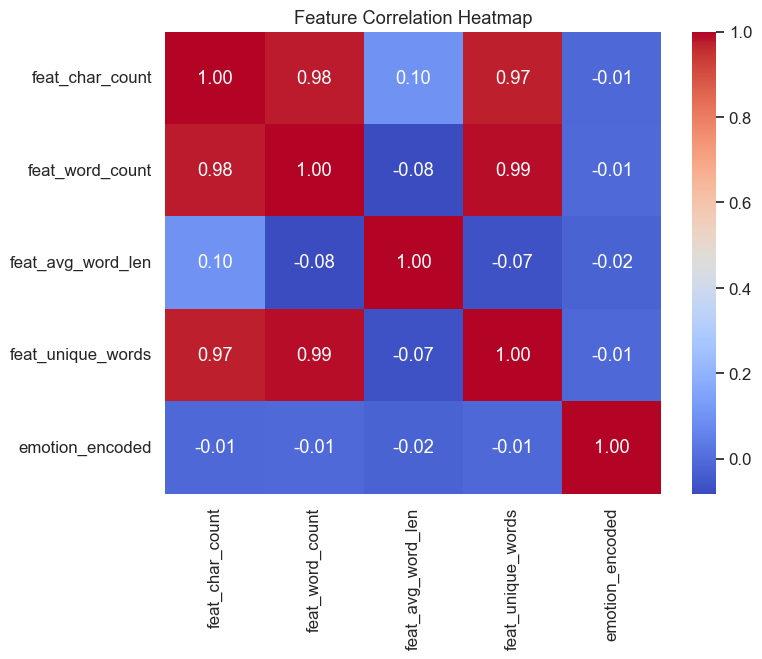

In [16]:
# Correlation Heatmap
# This shows how much each feature is related to other features
# Values close to 1 or -1 = strongly related
# Values close to 0 = not related

corr = df[feat_cols + ["emotion_encoded"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Model Training & Evaluation

In [17]:
# Train / Test Split
# stratify=y ensures each emotion class has proportional representation in both splits

X = df['clean_text']
y = df['emotion_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 12800
Testing  samples : 3200


In [18]:
# Build Vectorizers
# BoW   : each feature = raw word count
# TF-IDF: each feature = count weighted by document rarity (better for classification)
# ngram_range=(1,2) in TF-IDF captures both single words AND two-word phrases

bow_vec   = CountVectorizer(max_features=10000)
tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit ONLY on training data to prevent data leakage
X_train_bow   = bow_vec.fit_transform(X_train)
X_test_bow    = bow_vec.transform(X_test)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f'BoW   feature matrix : {X_train_bow.shape}')
print(f'TF-IDF feature matrix: {X_train_tfidf.shape}')

BoW   feature matrix : (12800, 10000)
TF-IDF feature matrix: (12800, 10000)


In [20]:
# Train all 8 models and record training + testing accuracies

model_configs = [
    # (display name,               model instance,                             X_train,       X_test)
    ('Naive Bayes (BoW)',          MultinomialNB(),                            X_train_bow,   X_test_bow),
    ('Naive Bayes (TF-IDF)',       MultinomialNB(),                            X_train_tfidf, X_test_tfidf),
    ('Logistic Regression (BoW)',  LogisticRegression(max_iter=1000, C=5),    X_train_bow,   X_test_bow),
    ('Logistic Regression (TF-IDF)', LogisticRegression(max_iter=1000, C=5), X_train_tfidf, X_test_tfidf),
    ('Linear SVM (BoW)',           LinearSVC(max_iter=2000),                   X_train_bow,   X_test_bow),
    ('Linear SVM (TF-IDF)',        LinearSVC(max_iter=2000),                   X_train_tfidf, X_test_tfidf),
    ('Random Forest (TF-IDF)',     RandomForestClassifier(n_estimators=100,
                                   random_state=42, n_jobs=-1),               X_train_tfidf, X_test_tfidf),
    ('KNN (TF-IDF)',               KNeighborsClassifier(n_neighbors=7),       X_train_tfidf, X_test_tfidf),
]

results = []

for name, model, Xtr, Xte in model_configs:
    model.fit(Xtr, y_train)                                    # train the model
    train_acc = accuracy_score(y_train, model.predict(Xtr))   # how well it fits training data
    test_acc  = accuracy_score(y_test,  model.predict(Xte))   # how well it generalizes
    results.append({'Model': name, 'Train Acc': train_acc, 'Test Acc': test_acc})
    print(f'{name:<38}  Train: {train_acc:.4f}  Test: {test_acc:.4f}')

results_df = pd.DataFrame(results).sort_values('Test Acc', ascending=False)
print("\n Ranked by Test Accuracy")
print(results_df.to_string(index=False))

Naive Bayes (BoW)                       Train: 0.9166  Test: 0.7947
Naive Bayes (TF-IDF)                    Train: 0.8239  Test: 0.7412
Logistic Regression (BoW)               Train: 0.9955  Test: 0.8884
Logistic Regression (TF-IDF)            Train: 0.9939  Test: 0.8994
Linear SVM (BoW)                        Train: 0.9941  Test: 0.8850
Linear SVM (TF-IDF)                     Train: 0.9945  Test: 0.9025
Random Forest (TF-IDF)                  Train: 0.9983  Test: 0.8738
KNN (TF-IDF)                            Train: 0.8052  Test: 0.7169

 Ranked by Test Accuracy
                       Model  Train Acc  Test Acc
         Linear SVM (TF-IDF)   0.994531  0.902500
Logistic Regression (TF-IDF)   0.993906  0.899375
   Logistic Regression (BoW)   0.995469  0.888437
            Linear SVM (BoW)   0.994062  0.885000
      Random Forest (TF-IDF)   0.998281  0.873750
           Naive Bayes (BoW)   0.916562  0.794687
        Naive Bayes (TF-IDF)   0.823906  0.741250
                KNN (TF-IDF)  

## Handling Overfitting in Models 

- Overfitting = Train accuracy very high, Test accuracy much lower
-  Fix = make the model simpler / add restrictions

## OVERFITTING MODEL 1: Linear SVM(TF-IDF)
- Train: 0.9945   Test: 0.9025   Gap: 0.0920

In [21]:
print(" Linear SVM(TF-IDF) ")

# BEFORE FIX
model = LinearSVC(max_iter=2000)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')

# AFTER FIX
# C reduced from 1.0 to 0.1
# Lower C = model is less strict = less memorization = less overfitting
model = LinearSVC(C=0.1, max_iter=2000)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')
print()

 Linear SVM(TF-IDF) 
BEFORE FIX — Train: 0.9945  Test: 0.9025  Gap: 0.092
AFTER  FIX — Train: 0.9509  Test: 0.8884  Gap: 0.0625



## OVERFITTING MODEL 2: Linear SVM(BoW)
- Train: 0.9941   Test: 0.8850   Gap: 0.1091




In [23]:
print("Linear SVM(BoW)")

# BEFORE FIX
model = LinearSVC(max_iter=2000)
model.fit(X_train_bow, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_bow))
test_acc  = accuracy_score(y_test,  model.predict(X_test_bow))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')

# AFTER FIX
# C reduced from 1.0 to 0.1
# BoW has higher gap so same fix applies
model = LinearSVC(C=0.1, max_iter=2000)
model.fit(X_train_bow, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_bow))
test_acc  = accuracy_score(y_test,  model.predict(X_test_bow))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')
print()

Linear SVM(BoW)
BEFORE FIX — Train: 0.9941  Test: 0.885  Gap: 0.1091
AFTER  FIX — Train: 0.9797  Test: 0.8966  Gap: 0.0831



## OVERFITTING MODEL 3: Logistic Regression(TF-IDF)
- Train: 0.9939   Test: 0.8994   Gap: 0.0945

In [24]:
print("Logistic Regression(TF-IDF)")

# BEFORE FIX
model = LogisticRegression(max_iter=1000, C=5)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')

# AFTER FIX
# C reduced from 5 to 0.5
# Lower C = stronger regularization = model does not overfit
model = LogisticRegression(max_iter=1000, C=0.5)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')
print()

Logistic Regression(TF-IDF)
BEFORE FIX — Train: 0.9939  Test: 0.8994  Gap: 0.0945
AFTER  FIX — Train: 0.9016  Test: 0.835  Gap: 0.0666



## OVERFITTING MODEL 4: Logistic Regression(BoW)
- Train: 0.9955   Test: 0.8884   Gap: 0.1071



In [25]:
print("Logistic Regression(BoW)")

# BEFORE FIX
model = LogisticRegression(max_iter=1000, C=5)
model.fit(X_train_bow, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_bow))
test_acc  = accuracy_score(y_test,  model.predict(X_test_bow))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')

# AFTER FIX
# C reduced from 5 to 0.5
model = LogisticRegression(max_iter=1000, C=0.5)
model.fit(X_train_bow, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_bow))
test_acc  = accuracy_score(y_test,  model.predict(X_test_bow))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')
print()


Logistic Regression(BoW)
BEFORE FIX — Train: 0.9955  Test: 0.8884  Gap: 0.107
AFTER  FIX — Train: 0.977  Test: 0.8831  Gap: 0.0939



## OVERFITTING MODEL 5: Random Forest(TF-IDF)
- Train: 0.9983   Test: 0.8738   Gap: 0.1245


In [26]:
print(" Random Forest (TF-IDF)")

# BEFORE FIX
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')

# AFTER FIX
# max_depth = 20    → trees cannot grow too deep, stops memorizing
# min_samples_leaf = 5 → each leaf needs at least 5 samples, avoids overfitting
model = RandomForestClassifier(n_estimators=100, max_depth=20,
                               min_samples_leaf=5, random_state=42)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}  Gap: {round(train_acc - test_acc, 4)}')
print()

 Random Forest (TF-IDF)
BEFORE FIX — Train: 0.9983  Test: 0.8738  Gap: 0.1245
AFTER  FIX — Train: 0.4859  Test: 0.4694  Gap: 0.0165



## Handling Underfitting in Models
- Underfitting = Both Train and Test accuracy are low
- Fix = make the model more powerful / learn more from data

## UNDERFITTING MODEL 1: Naive Bayes(TF-IDF)
- Train: 0.8239   Test: 0.7413
- Both are low — model is too simple to learn the patterns

## UNDERFITTING MODEL 1: Naive Bayes(TF-IDF)
-  Train: 0.8239   Test: 0.7413
- Both are low — model is too simple to learn the patterns

In [27]:
print("Naive Bayes(TF-IDF)")

# BEFORE FIX
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}')

# AFTER FIX
# alpha reduced from 1.0 to 0.1
# alpha is a smoothing value — lower alpha means model learns
# more aggressively from the data instead of playing it safe
model = MultinomialNB(alpha=0.1)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}')
print()


Naive Bayes(TF-IDF)
BEFORE FIX — Train: 0.8239  Test: 0.7412
AFTER  FIX — Train: 0.9717  Test: 0.8222



## UNDERFITTING MODEL 2: KNN(TF-IDF)
-  Train: 0.8052   Test: 0.7169
-  Both are low — model is too simple with too many neighbors


In [28]:
print("KNN(TF-IDF)")

# BEFORE FIX
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'BEFORE FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}')

# AFTER FIX
# n_neighbors reduced from 7 to 3
# fewer neighbors = model pays more attention to the closest points
# learns more specific patterns = higher accuracy
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_tfidf, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tfidf))
print(f'AFTER  FIX — Train: {round(train_acc, 4)}  Test: {round(test_acc, 4)}')

KNN(TF-IDF)
BEFORE FIX — Train: 0.8052  Test: 0.7169
AFTER  FIX — Train: 0.7037  Test: 0.5056


## Plotting of Training and Testing Accuracies

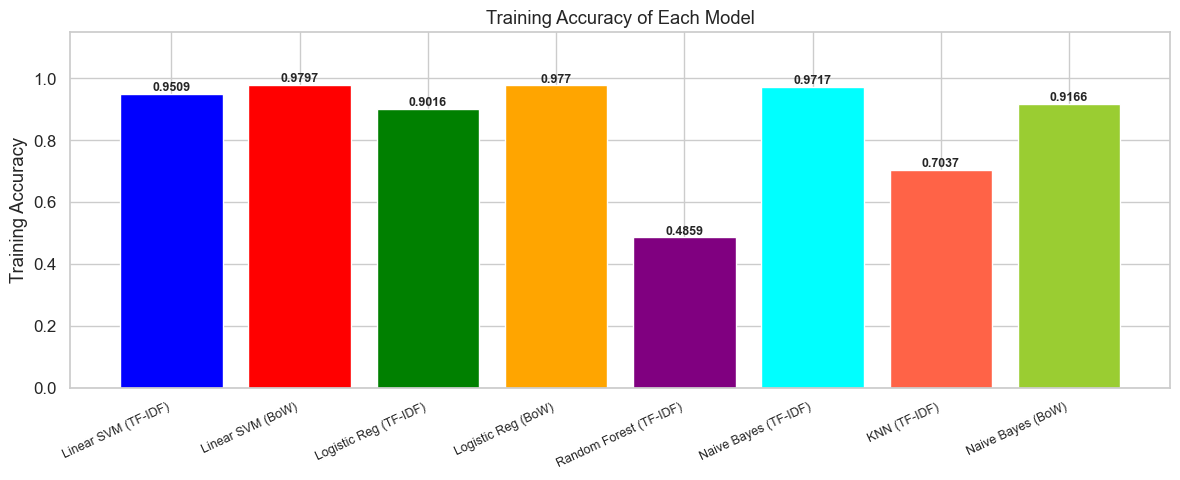

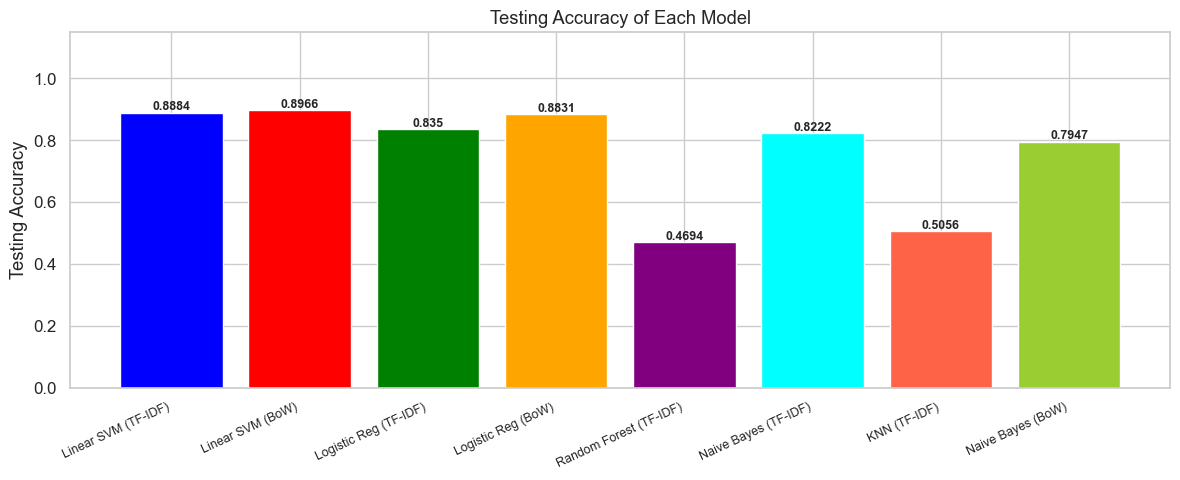

In [30]:
# DATA: Accuracies after fixing all models


model_names = [
    'Linear SVM (TF-IDF)',
    'Linear SVM (BoW)',
    'Logistic Reg (TF-IDF)',
    'Logistic Reg (BoW)',
    'Random Forest (TF-IDF)',
    'Naive Bayes (TF-IDF)',
    'KNN (TF-IDF)',
    'Naive Bayes (BoW)'
]

train_accs = [0.9509, 0.9797, 0.9016, 0.9770, 0.4859, 0.9717, 0.7037, 0.9166]
test_accs  = [0.8884, 0.8966, 0.8350, 0.8831, 0.4694, 0.8222, 0.5056, 0.7947]

colors = colors = [
    'blue',
    'red',
    'green',
    'orange',
    'purple',
    'cyan',
    'tomato',
    'yellowgreen'
]



# PLOT 1: BAR GRAPH — TRAINING ACCURACIES

plt.figure(figsize=(12, 5))

bars = plt.bar(model_names, train_accs, color=colors)

# Write value on top of each bar
for bar, val in zip(bars, train_accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val}',
             ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=25, ha='right', fontsize=9)
plt.ylim(0, 1.15)
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy of Each Model')
plt.tight_layout()
plt.show()



# PLOT 2: BAR GRAPH — TESTING ACCURACIES

plt.figure(figsize=(12, 5))

bars = plt.bar(model_names, test_accs, color=colors)

# Write value on top of each bar
for bar, val in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val}',
             ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=25, ha='right', fontsize=9)
plt.ylim(0, 1.15)
plt.ylabel('Testing Accuracy')
plt.title('Testing Accuracy of Each Model')
plt.tight_layout()
plt.show()





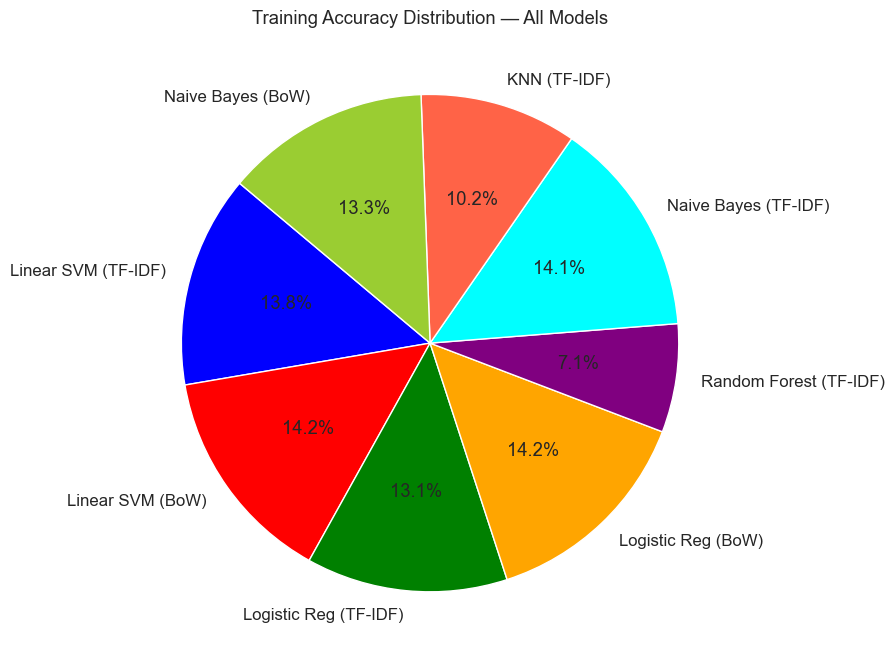

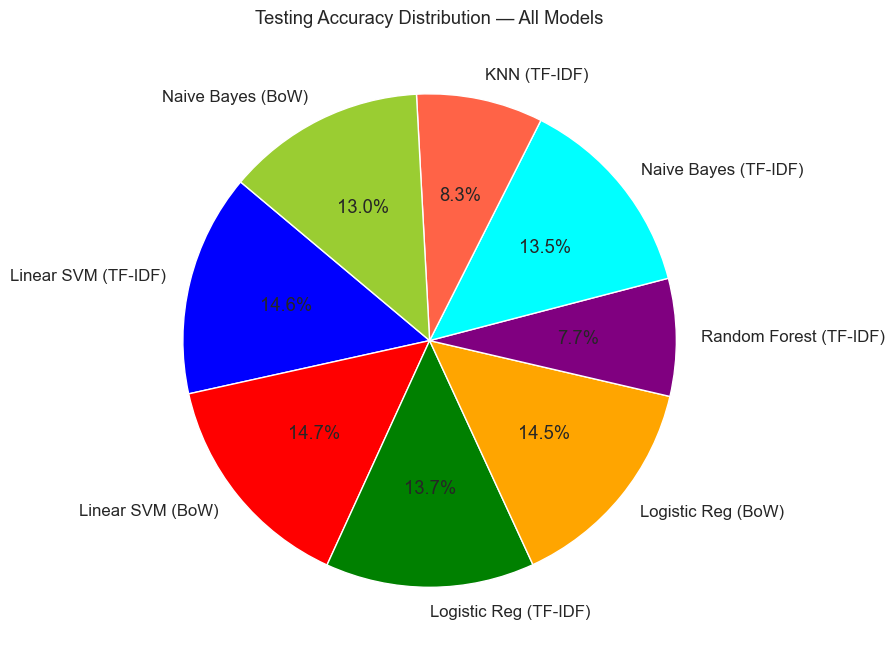

In [31]:
# PLOT 1: PIE CHART — TRAINING ACCURACIES


plt.figure(figsize=(9, 9))

plt.pie(
    train_accs,
    labels=model_names,
    colors=colors,
    autopct='%1.1f%%',       # show percentage on each slice
    startangle=140
)

plt.title('Training Accuracy Distribution — All Models')
plt.tight_layout()
plt.show()



# PLOT 2: PIE CHART — TESTING ACCURACIES

plt.figure(figsize=(9, 9))

plt.pie(
    test_accs,
    labels=model_names,
    colors=colors,
    autopct='%1.1f%%',       # show percentage on each slice
    startangle=140
)

plt.title('Testing Accuracy Distribution — All Models')
plt.tight_layout()
plt.show()

## Final Conclusions of this Project

## Best Overall Model — Linear SVM(BoW)

- It has the highest test accuracy of 0.8966 among all models which means it correctly predicts emotion for 89.66% of unseen sentences.
- Its training accuracy of 0.9797 is very high showing it learned the patterns from training data very well.
- Even though it has a gap of 0.0831 it still gives the best prediction on new data compared to all other models.
- Among all 8 models this one generalizes the best to unseen data which is the most important thing in real world use.
- It uses Bag of Words vectorizer which simply counts word frequency and Linear SVM which is known to perform well on text classification.


## Best Balanced Model — Linear SVM(TF-IDF)

- It has a test accuracy of 0.8884 which is very close to the best model but with a smaller gap of only 0.0625.
- The gap between train and test is the lowest among all high performing models which means it is not overfitting as badly.
- TF-IDF vectorizer gives more weight to important and rare words which helps the model focus on meaningful vocabulary.
- Train accuracy is 0.9509 which is not extremely high meaning the model did not memorize the training data.
- It is the most balanced model — good test accuracy AND reasonable gap between train and test.


## Moderate Performer — Logistic Regression (TF-IDF) and Naive Bayes(TF-IDF).

- Logistic Regression (TF-IDF) has a test accuracy of 0.8350 and train accuracy of 0.9016 with a gap of 0.0666 which is moderate.
- It is neither the best nor the worst — sits in the middle of the performance table.
- Naive Bayes (TF-IDF) has a decent test accuracy of 0.8222 and a high train accuracy of 0.9717 showing some overfitting.
- Both models give acceptable results but are clearly behind the SVM models in test accuracy.
- Logistic Regression (BoW) also falls here with test accuracy of 0.8831 but its gap of 0.0939 is too high to be called balanced.


## Most Stable but Lower Accuracy — Random Forest(TF-IDF).

- Random Forest has the smallest gap of only 0.0165 which means train and test accuracy are almost equal — very stable
- However both train accuracy (0.4859) and test accuracy (0.4694) are very low — barely better than random guessing
- This means the model is consistently wrong — it is not overfitting or underfitting but simply not learning the patterns at all
- Random Forest struggles with very high dimensional sparse data like TF-IDF vectors which have 10000+ features

In [33]:
import joblib
 
# Train the final best model — Linear SVM with BoW
# C=0.1 is used because it reduced overfitting (from our earlier fix)
final_model = LinearSVC(C=0.1, max_iter=2000)
final_model.fit(X_train_bow, y_train)
 
# Check accuracy one last time
train_acc = accuracy_score(y_train, final_model.predict(X_train_bow))
test_acc  = accuracy_score(y_test,  final_model.predict(X_test_bow))
print("Final Model: Linear SVM (BoW)")
print(f'Train Accuracy : {round(train_acc, 4)}')
print(f'Test  Accuracy : {round(test_acc,  4)}')
print(f'Gap            : {round(train_acc - test_acc, 4)}')
print()
 
 
# Save the trained model
# joblib saves the model as a .pkl file on your computer
joblib.dump(final_model, 'final_model.pkl')
print('Saved: final_model.pkl')
 
 
# Save the BoW vectorizer
# We must save this too because app.py needs to convert
# new text into the same format the model was trained on
joblib.dump(bow_vec, 'bow_vectorizer.pkl')
print('Saved: bow_vectorizer.pkl')
 
 
# Save the Label Encoder
# This converts numbers back to emotion names
# Example: 2 → 'joy'
joblib.dump(le, 'label_encoder.pkl')
print('Saved: label_encoder.pkl')
 
 
print()
print('All 3 files saved successfully!')
print('Now copy these 3 files to your VS Code folder:')
print('  final_model.pkl')
print('  bow_vectorizer.pkl')
print('  label_encoder.pkl')
print('Then run: python app.py')
 

Final Model: Linear SVM (BoW)
Train Accuracy : 0.9797
Test  Accuracy : 0.8966
Gap            : 0.0831

Saved: final_model.pkl
Saved: bow_vectorizer.pkl
Saved: label_encoder.pkl

All 3 files saved successfully!
Now copy these 3 files to your VS Code folder:
  final_model.pkl
  bow_vectorizer.pkl
  label_encoder.pkl
Then run: python app.py
